<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/phonchi/CryoParticleSegment/blob/main/notebook/01_training_models_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

### CryoParticleSegment

In [ ]:
%pip install torchinfo -qq
%pip install -U git+https://github.com/qubvel/segmentation_models.pytorch -qq

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
%pip install mrcfile -qq

## ⭐ Setup
You must run all codes under this category.

### ✅ Directory Settings

In [ ]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [ ]:
# @title  { display-mode: "form" }

IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/TpzD_output/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
LABEL_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/output/dataset/10017/micrographs_ground_np" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/TpzD_output/results/10017_test/unet_eb5_dice" # @param {type:"string"}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# @title  { display-mode: "form" }
# @markdown Detect whether using folder in Google Drive as **`RESULT DIR`**📁.

if "content" in IMAGE_DIR.split("/")[:3] or "content" in LABEL_DIR.split("/")[:3]:
  try:
    from google.colab import drive
    drive.mount('/content/drive')
    !rm -r /content/sample_data
    if "content" in IMAGE_DIR.split("/")[:3]:
      !cp -r {IMAGE_DIR} /content/image_dir # Do not need test
      IMAGE_DIR = "/content/image_dir"
    if "content" in LABEL_DIR.split("/")[:3]:
      !cp -r {LABEL_DIR} /content/label_dir
      LABEL_DIR = "/content/label_dir"
  except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
rm: cannot remove '/content/sample_data': No such file or directory


In [ ]:
!git clone https://github.com/phonchi/CryoParticleSegment.git

fatal: destination path 'CryoParticleSegment' already exists and is not an empty directory.


In [ ]:
import sys
import os

# Adjust the path relative to your current working directory
module_path = os.path.abspath('CryoParticleSegment/Modeling')

# Add to sys.path if it's not already included
if module_path not in sys.path:
    sys.path.append(module_path)

### ✅ Packages Handling

In [ ]:
# @title  { display-mode: "form" }
# @markdown Useful packages.

import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, OneCycleLR
# Causion the attribute "verbose" in the OneCycleLR had been deprecated' (to not approve, but for CS deprecated meeans that for the current or the future version the object had been removed)
# Verbose If True, prints a message to stdout for each update.
#  (To access the learning rate use the get_last_lr())

In [ ]:
# @title  { display-mode: "form" }
# @markdown User-defined packages.

from dataset import MicrographDataset, MicrographDatasetEvery
from dataset import reconstruct_patched
from model import create_model
from trainer import CryoEMEvaluator
from trainer import CryoEMTrainerWithScheduler, tqdm_plugin_for_Trainer

## ⭐ Main

### ✅ Setting

In [ ]:
# @markdown Parameters.

user = True # @param {type:"boolean"}

In [ ]:
NUM_CLASSES = 2
EPOCHS = 100
BATCH = 7
CROP_SIZE = (512, 512)
LR = 1e-3
RLR_PATIENCE = 3
ES_PATIENCE = 40
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# @markdown Set seed.

random_state = 42
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

### ✅ Dataset

You can provide a [`transforms.CenterCrop(3840)`](https://docs.pytorch.org/vision/master/generated/torchvision.transforms.CenterCrop.html) object to crop out boundary artifacts.


In [ ]:
crop = transforms.CenterCrop(3840)

In [ ]:
train_dir = os.path.join(IMAGE_DIR, 'train')
train_filenames = np.loadtxt(f"{IMAGE_DIR}/train_filenames.txt", dtype=str)
train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)

In [ ]:
val_dir = os.path.join(IMAGE_DIR, 'val')
val_filenames = np.loadtxt(f"{IMAGE_DIR}/val_filenames.txt", dtype=str)
val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
val_loader = DataLoader(val_dataset, batch_size=None, shuffle=False, pin_memory=True)

In [ ]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=test_filenames, crop_size=CROP_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True)

In [ ]:
for i1, i2, i3, i4 in val_loader: #test loader and reconstruct
    print(i2.dtype, i4.dtype)
    print(i2.shape, i4.shape)
    break

torch.int64 torch.int64
torch.Size([81, 1, 512, 512]) torch.Size([1, 3840, 3840])


## ⭐ Convcrf wtih FCN finetuned on cryoem

## The model

The platform is built on top of `segmentation_models.pytorch`. Most segmentation models, encoders, and loss functions are expected to work out of the box, although some untested options may require minor modifications.

You can find the available [models here](https://smp.readthedocs.io/en/latest/models.html), [encoders here](https://smp.readthedocs.io/en/latest/models.html), and [loss functions here](https://smp.readthedocs.io/en/latest/losses.html). You can also customize your own modules, as described [here](https://smp.readthedocs.io/en/latest/insights.html).

### ✅ Model

In [ ]:
# @title  { display-mode: "form" }

architecture = "Unet++" # @param {type:"string"}
encoder = "timm-efficientnet-b5" # @param {type:"string"}
pretrained = True # @param {type:"boolean"}
loss = "dice" # @param {type:"string"}

In [ ]:
import segmentation_models_pytorch as smp

if pretrained:
  weights = "advprop"
else:
  weights = None

if architecture == "Unet++":
    backbone = smp.UnetPlusPlus(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` or `advprop` for pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )

elif architecture == "Deeplab":
    backbone = smp.DeepLabV3(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )
else:
    print("Architecture not supported")
    raise NotImplementedError

model = create_model(backbone, addout=True) #crf_args

In [ ]:
print(model)

Model_Out(
  (backbone): UnetPlusPlus(
    (encoder): EfficientNetEncoder(
      (conv_stem): Conv2d(1, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNormAct2d(
        48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Swish()
      )
      (blocks): Sequential(
        (0): Sequential(
          (0): DepthwiseSeparableConv(
            (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (bn1): BatchNormAct2d(
              48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): Swish()
            )
            (aa): Identity()
            (se): SqueezeExcite(
              (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
              (act1): Swish()
              (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
              (gate):

In [ ]:
from torchinfo import summary
summary(model, input_size=(BATCH, 1, 512, 512))

Layer (type:depth-idx)                                  Output Shape              Param #
Model_Out                                               [7, 2, 512, 512]          --
├─UnetPlusPlus: 1-1                                     [7, 2, 512, 512]          --
│    └─EfficientNetEncoder: 2-1                         [7, 1, 512, 512]          1,052,672
│    │    └─Conv2d: 3-1                                 [7, 48, 256, 256]         432
│    │    └─BatchNormAct2d: 3-2                         [7, 48, 256, 256]         96
│    │    └─Sequential: 3-3                             --                        27,286,720
│    └─UnetPlusPlusDecoder: 2-2                         [7, 16, 512, 512]         --
│    │    └─ModuleDict: 3-4                             --                        3,569,152
│    └─SegmentationHead: 2-3                            [7, 2, 512, 512]          --
│    │    └─Conv2d: 3-5                                 [7, 2, 512, 512]          290
│    │    └─Identity: 3-6           

Note that for the Tversky loss when $a = b = 0.5$, the loss reduces to the Dice loss, which is the default setting in this study. Tversky loss provides explicit control over the balance between false positives and false negatives, making it particularly useful when the goal is to harvest more particles. Specifically, decreasing $a$ increases recall, while decreasing $b$ increases precision.

In [ ]:
import math
if loss == "dice":
    criterion = smp.losses.DiceLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "cross_entropy":
    criterion = smp.losses.SoftCrossEntropyLoss(smooth_factor=0.1)
elif loss == "jaccard":
    criterion = smp.losses.JaccardLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "Lovasz":
    criterion = smp.losses.LovaszLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "Tversky":
    criterion = smp.losses.TverskyLoss(smp.losses.MULTICLASS_MODE, from_logits=True, alpha=0.7, beta=0.3, gamma=1, smooth=0.1)
else:
    print("Loss not supported")
    raise NotImplementedError
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
#scheduler = ReduceLROnPlateau(optimizer, patience=RLR_PATIENCE, verbose=True)
scheduler = OneCycleLR(optimizer, max_lr=LR, steps_per_epoch=math.ceil(len(train_dataset)/BATCH), epochs=EPOCHS)

In [ ]:
!mkdir -p {RESULT_DIR}

### ✅ Training

In [ ]:
# Unet++ eb5 Dice denoise2
Trainer = tqdm_plugin_for_Trainer(CryoEMTrainerWithScheduler)
trainer = Trainer(model, train_dataset, criterion, optimizer, DEVICE,
              num_classes = NUM_CLASSES,
              lr_scheduler=scheduler, patience=ES_PATIENCE)

trainer.train(EPOCHS, val_loader=val_loader, batch_size = BATCH,
              ckpt_dir = RESULT_DIR, random_state = random_state)


Epoch   1/100:


Training:   0%|          | 0/2 [00:00<?, ?it/s]

Parameter Group 0, Learning Rate: 4.271929589913417e-05
Training score:
  loss	: 0.4922


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Validation score:
  loss : 0.7193
Iou by Class: [0.03632113 0.21849214]
Precision by Class: [0.7660464  0.22047548]
Recall by Class: [0.03672854 0.9604564 ]
Accuracy by Class: [0.24085289 0.24085289]
F1_score by Class: [0.07009627 0.35862708]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/TpzD_output/results/10017_test/unet_eb5_dice/checkpoint1.pt
Loss improve to 0.7193108201026917.
Epoch   2/100:


...

Validation score:
  loss : 0.2007
Iou by Class: [0.87629044 0.6178603 ]
Precision by Class: [0.9307878  0.77356225]
Recall by Class: [0.9373693  0.75427973]
Accuracy by Class: [0.89691037 0.89691037]
F1_score by Class: [0.93406695 0.7637993 ]
No improvement for 31 epoch.
Epoch 100/100:


Training:   0%|          | 0/2 [00:00<?, ?it/s]

Parameter Group 0, Learning Rate: 1.2988202521661969e-07
Training score:
  loss	: 0.1304


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Validation score:
  loss : 0.2016
Iou by Class: [0.8766803 0.616582 ]
Precision by Class: [0.9295047  0.77725965]
Recall by Class: [0.9391215 0.7489104]
Accuracy by Class: [0.8970888 0.8970888]
F1_score by Class: [0.9342883  0.76282173]
No improvement for 32 epoch.


In [ ]:
import pickle

trainer_result = {
    'val_results': trainer.val_results,
    'best_epoch': trainer.best_epoch,
    'best_loss': trainer.best_loss,
    'train_loss': trainer.train_loss,
    'loss': trainer.loss,
}

with open(f'{RESULT_DIR}/trainer_result.pickle', 'wb') as f:
    pickle.dump(trainer_result, f)

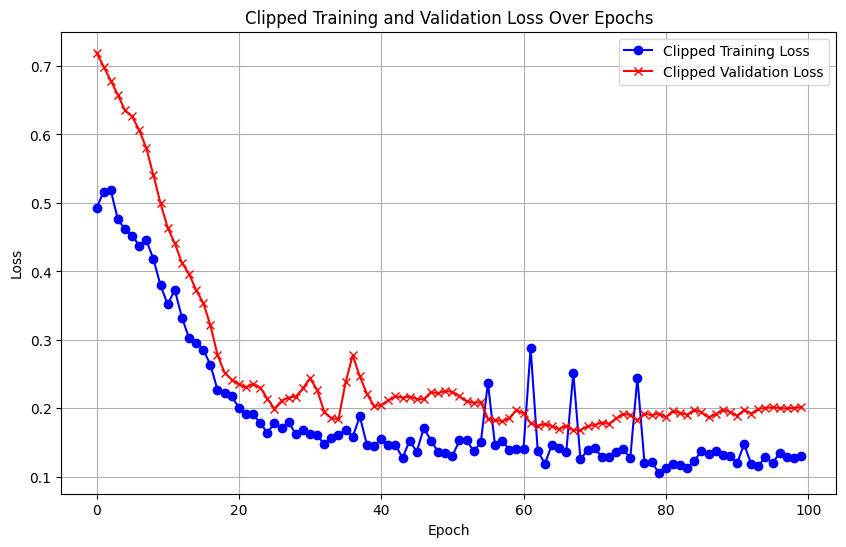

In [ ]:
import matplotlib.pyplot as plt

train_losses = trainer_result['train_loss']
val_losses = trainer_result['loss']  # Assuming 'loss' contains the validation losses

max_loss = 1  # Set a threshold for maximum loss to visualize

clipped_train_losses = [min(loss, max_loss) for loss in train_losses]
clipped_val_losses = [min(loss, max_loss) for loss in val_losses]

plt.figure(figsize=(10, 6))
plt.plot(clipped_train_losses, label='Clipped Training Loss', color='blue', marker='o')
plt.plot(clipped_val_losses, label='Clipped Validation Loss', color='red', marker='x')
plt.title('Clipped Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

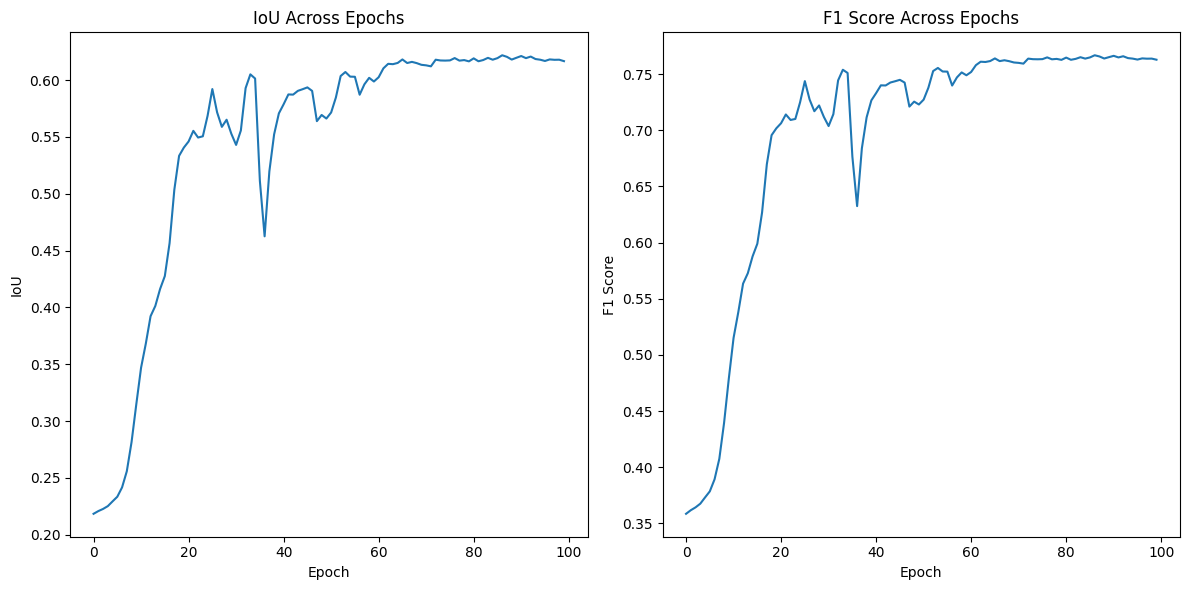

In [ ]:
# Initialize lists to store IoU and F1-scores
ious = []
f1_scores = []

# Extract IoU and F1-score from each OrderedDict
for entry in trainer.val_results:
    ious.append(entry['iou'][1])
    f1_scores.append(entry['f1_score'][1])

# Convert lists to arrays for easier handling
ious = np.array(ious)
f1_scores = np.array(f1_scores)

# Plotting
plt.figure(figsize=(12, 6))

# Plot IoU
plt.subplot(1, 2, 1)
plt.plot(ious)  # Assuming you want the mean IoU of each epoch
plt.title('IoU Across Epochs')
plt.xlabel('Epoch')
plt.ylabel('IoU')

# Plot F1-score
plt.subplot(1, 2, 2)
plt.plot(f1_scores)  # Assuming you want the mean F1-score of each epoch
plt.title('F1 Score Across Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')

plt.tight_layout()
plt.show()

## ⭐ Evaluate

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

from torchvision.utils import save_image
from dataset import reconstruct_patched

def simple_micrograph_preprocessing(micrograph):
  micrograph_copy = micrograph.copy()
  micrograph_copy = (micrograph_copy-micrograph.mean()+2.5*micrograph.std())/5/micrograph.std()
  micrograph_copy[micrograph_copy<0]=0
  micrograph_copy[micrograph_copy>1]=1
  return micrograph_copy

!mkdir {RESULT_DIR}/Each_ckpt

In [ ]:
# Check the last five best epochs

if not user:
    checkpoint_paths = [path for path in os.listdir(RESULT_DIR) if '.pt' in path]
    for checkpoint_path in checkpoint_paths[-5:]:
        state_dict_path = f"{RESULT_DIR}/{checkpoint_path}"
        state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        print("\nLoad model at: ", state_dict_path)
        #trainer = CryoEMTrainerWithScheduler(model, train_dataset, criterion, optimizer, device,
        #              num_classes=NUM_CLASSES,
        #              lr_scheduler=scheduler, patience=ES_PATIENCE)
        #result = trainer.evaluate(test_loader)
        model.to(DEVICE)
        model.eval()
        mini_batch_size = 9  # Number of patches to process at once
        with torch.no_grad():
            idx, (test_image, _, grid, _) = next(enumerate(test_dataset))
            inputs = test_image.to(DEVICE)
            num_batches = (inputs.size(0) + mini_batch_size - 1) // mini_batch_size
            patched_outputs = []

            for batch_idx in range(num_batches):
                start_idx = batch_idx * mini_batch_size
                end_idx = min(start_idx + mini_batch_size, inputs.size(0))
                patch_input = inputs[start_idx:end_idx].to(DEVICE)
                output = model(patch_input)['out']
                patched_outputs.append(output.cpu())  # Move to CPU to conserve GPU memory

                del patch_input
                torch.cuda.empty_cache()
            outputs = torch.cat(patched_outputs).to(DEVICE)  # Move to CPU to conserve GPU memory
            del patched_outputs
            torch.cuda.empty_cache()
            preds = outputs.argmax(dim=1).unsqueeze(1).cpu().detach()  # Now preds will have shape [81, 1, 512, 512]

            ## Plotting
            micrograph = np.load(f"{IMAGE_DIR}/val/{val_filenames[idx][:-4]}.npy")
            label_path = f"{LABEL_DIR}/{val_filenames[idx][:-4]}.png"


            micrograph_copy = simple_micrograph_preprocessing(micrograph)
            #crop_amount = 128  # Amount cropped from each side of the label image
            mic_width, mic_height = micrograph_copy.shape[1], micrograph_copy.shape[0]

            # Calculate starting and ending indices for cropping the micrograph
            #start_x = int((mic_width - 3840) / 2)
            #end_x = start_x + 3840
            #start_y = int((mic_height - 3840) / 2)
            #end_y = start_y + 3840

            # Crop the micrograph
            cropped_micrograph = micrograph_copy
            pred_image = reconstruct_patched(preds, grid).float()

            _,ax = plt.subplots(figsize=(12, 12))
            ax.imshow(cropped_micrograph, cmap='gray')
            ax.imshow(pred_image.squeeze(), cmap='inferno', alpha=0.4)
            plt.show()
            ##

            filename = f"{os.path.splitext(checkpoint_path)[0]}.png"
            pred_path = os.path.join(RESULT_DIR, "Each_ckpt", filename)
            save_image(pred_image, pred_path)

### ✅ Testing

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    np.random.seed(24)
    selected_filenames = np.random.choice(test_filenames, size=6, replace=False)
    print(selected_filenames)
    test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=selected_filenames, crop_size=CROP_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True)

In [ ]:
evaluator = CryoEMEvaluator(
    model=model, device=DEVICE, metrics=['AP','iou'],
    num_classes=NUM_CLASSES)
print("ConvCRF validation result:")
result = evaluator.evaluate(loader=val_loader)
if not user:
    print("ConvCRF test result:")
    result = evaluator.evaluate(loader=test_loader)

ConvCRF validation result:
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
Iou by Class: [0.87668085 0.61658245]
Precision by Class: [0.9295044 0.7772622]
Recall by Class: [0.9391225  0.74890894]
Accuracy by Class: [0.8970893 0.8970893]
F1_score by Class: [0.9342887  0.76282215]
